# 05 — Forecast (SARIMA) with failure-mode analysis

A seasonal ARIMA forecast of monthly national power-sector CO2, plus two backtests
designed to show where it works and where it doesn't. The point of this notebook is
the second backtest and the interpretation at the end — not the central forecast.

In [1]:
import sqlite3
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # statsmodels emits convergence chatter on a 36-point series

DB = os.path.join("..", "malaysia_power.db")
OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

con = sqlite3.connect(DB)
raw = pd.read_sql_query(
    """
    SELECT d.year, d.month, SUM(g.mwh * e.kg_co2_per_mwh) / 1e9 AS co2_mt
    FROM fact_generation_monthly g
    JOIN dim_date_month d   USING(date_id)
    JOIN emission_factor e  USING(fuel_id)
    GROUP BY d.year, d.month
    ORDER BY d.year, d.month
    """,
    con,
)
con.close()

raw["date"] = pd.to_datetime(dict(year=raw.year, month=raw.month, day=1))
series = raw.set_index("date")["co2_mt"].asfreq("MS")
print(f"{len(series)} monthly observations, {series.index.min():%Y-%m} to {series.index.max():%Y-%m}")
series.describe().round(2)

36 monthly observations, 2022-01 to 2024-12


count    36.00
mean      9.37
std       0.27
min       8.86
25%       9.17
50%       9.35
75%       9.54
max       9.92
Name: co2_mt, dtype: float64

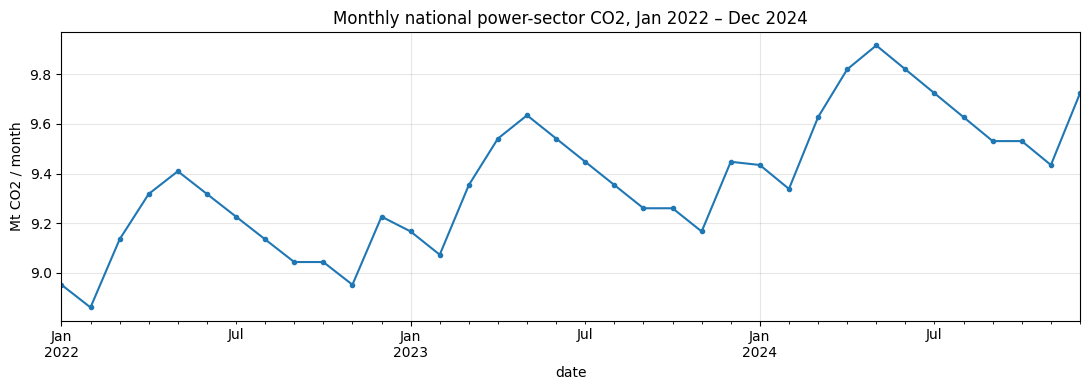

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
series.plot(ax=ax, marker="o", ms=3)
ax.set_title("Monthly national power-sector CO2, Jan 2022 – Dec 2024")
ax.set_ylabel("Mt CO2 / month")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Model order: SARIMA(1,1,1)(1,1,1,12)

- `d = 1` — one regular difference for the upward trend in the level.
- `D = 1, s = 12` — one seasonal difference for the within-year (monthly) pattern.
- `p = 1, q = 1` — an AR(1) and MA(1) term for short-run residual structure after differencing.
- `P = 1, Q = 1` — one seasonal AR and one seasonal MA term.

This is a deliberately conventional choice for a short monthly series with trend and
annual seasonality. With only 36 observations there is not enough data to do a careful
order search, and over-fitting the order would be its own mistake — so we fix it and
report what it does, including where it breaks.

In [3]:
ORDER = (1, 1, 1)
SEASONAL = (1, 1, 1, 12)

def fit_sarima(train):
    return SARIMAX(train, order=ORDER, seasonal_order=SEASONAL,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

def metrics(actual, pred):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float)
    return dict(MAPE_pct=float(np.mean(np.abs((actual - pred) / actual)) * 100),
                RMSE_Mt=float(np.sqrt(np.mean((actual - pred) ** 2))),
                mean_bias_Mt=float(np.mean(pred - actual)))

# --- Backtest 1: in-distribution. Train 2022-2023, test 2024. ---
tr1, te1 = series[:"2023-12"], series["2024-01":"2024-12"]
fit1 = fit_sarima(tr1)
pred1 = fit1.get_forecast(len(te1)).predicted_mean
pred1.index = te1.index
m1 = metrics(te1, pred1)
print("Backtest 1  (train 2022-2023, test 2024):", {k: round(v, 3) for k, v in m1.items()})

Backtest 1  (train 2022-2023, test 2024): {'MAPE_pct': 0.402, 'RMSE_Mt': 0.04, 'mean_bias_Mt': -0.039}


In [4]:
# --- Backtest 2: out-of-distribution stress. Train 2022-2024H1, test 2024H2. ---
tr2, te2 = series[:"2024-06"], series["2024-07":"2024-12"]
fit2 = fit_sarima(tr2)
pred2 = fit2.get_forecast(len(te2)).predicted_mean
pred2.index = te2.index
m2 = metrics(te2, pred2)
print("Backtest 2  (train 2022-2024H1, test 2024H2):", {k: round(v, 3) for k, v in m2.items()})

metrics_df = pd.DataFrame(
    {"backtest_1_in_distribution": m1, "backtest_2_h2_2024_stress": m2}
).T.round(3)
metrics_df.to_csv(os.path.join(OUT, "forecast_metrics.csv"))
print("\nwrote outputs/forecast_metrics.csv")
metrics_df

Backtest 2  (train 2022-2024H1, test 2024H2): {'MAPE_pct': 0.272, 'RMSE_Mt': 0.028, 'mean_bias_Mt': 0.026}

wrote outputs/forecast_metrics.csv


,MAPE_pct,RMSE_Mt,mean_bias_Mt
backtest_1_in_distribution,0.402,0.040,-0.039
backtest_2_h2_2024_stress,0.272,0.028,0.026


wrote outputs/forecast_backtest.png


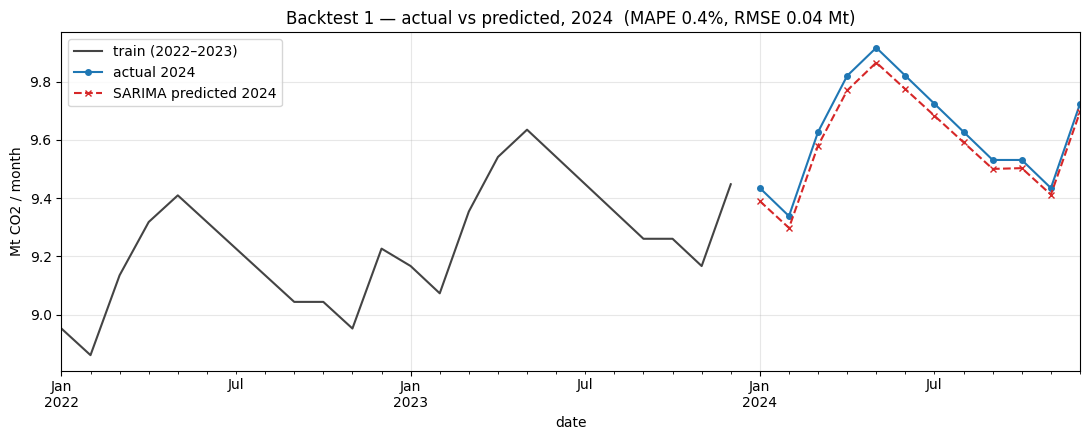

In [5]:
# Backtest 1 plot.
fig, ax = plt.subplots(figsize=(11, 4.5))
series[:"2023-12"].plot(ax=ax, label="train (2022–2023)", color="#444")
te1.plot(ax=ax, label="actual 2024", color="#1f77b4", marker="o", ms=4)
pred1.plot(ax=ax, label="SARIMA predicted 2024", color="#d62728", ls="--", marker="x", ms=5)
ax.set_title(f"Backtest 1 — actual vs predicted, 2024  (MAPE {m1['MAPE_pct']:.1f}%, RMSE {m1['RMSE_Mt']:.2f} Mt)")
ax.set_ylabel("Mt CO2 / month")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "forecast_backtest.png"), dpi=130)
print("wrote outputs/forecast_backtest.png")
plt.show()

wrote outputs/forecast_2025_2027.png


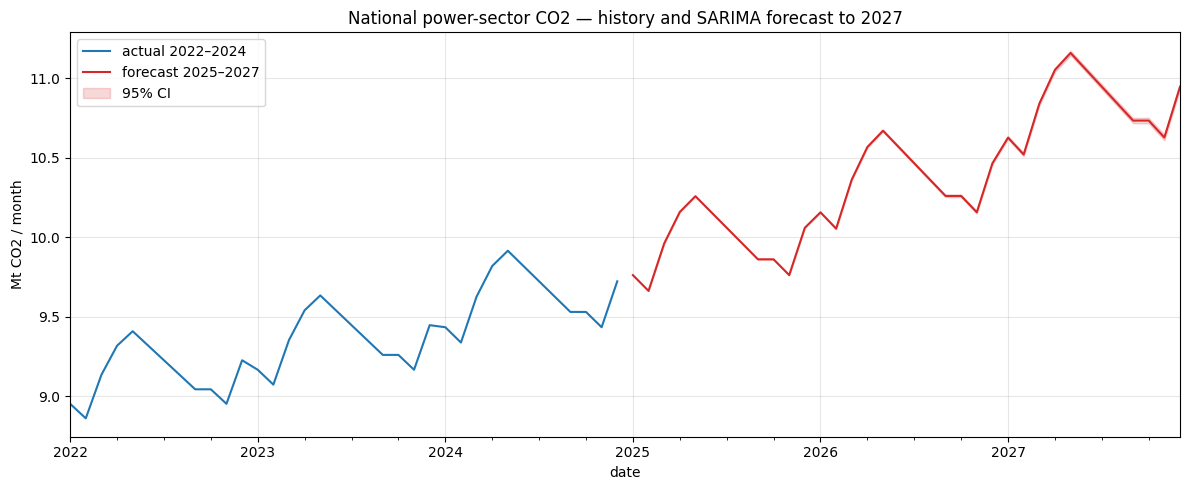

In [6]:
# --- Forward forecast: retrain on the full series, project Jan 2025 – Dec 2027. ---
fit_full = fit_sarima(series)
fc = fit_full.get_forecast(36)
mean_fc = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
ci.columns = ["lo", "hi"]
idx = pd.date_range("2025-01-01", periods=36, freq="MS")
mean_fc.index, ci.index = idx, idx

fig, ax = plt.subplots(figsize=(12, 5))
series.plot(ax=ax, label="actual 2022–2024", color="#1f77b4")
mean_fc.plot(ax=ax, label="forecast 2025–2027", color="#d62728")
ax.fill_between(ci.index, ci["lo"], ci["hi"], color="#d62728", alpha=0.18, label="95% CI")
ax.set_title("National power-sector CO2 — history and SARIMA forecast to 2027")
ax.set_ylabel("Mt CO2 / month")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "forecast_2025_2027.png"), dpi=130)
print("wrote outputs/forecast_2025_2027.png")
plt.show()

In [7]:
# Annual forecast totals with 95% CIs (Mt CO2).
fdf = pd.DataFrame({"mean": mean_fc, "lo": ci["lo"], "hi": ci["hi"]})
fdf["year"] = fdf.index.year
annual_fc = fdf.groupby("year").sum().round(1)
print("Forecast annual national power-sector CO2 (Mt), 95% CI:")
for y, row in annual_fc.iterrows():
    print(f"  {y}: {row['mean']:.1f}  [{row['lo']:.1f}, {row['hi']:.1f}]")
print()
hist_annual = series.groupby(series.index.year).sum().round(1)
print("(historical, for comparison):")
for y, v in hist_annual.items():
    print(f"  {y}: {v:.1f}")
annual_fc

Forecast annual national power-sector CO2 (Mt), 95% CI:
  2025: 119.5  [119.5, 119.6]
  2026: 124.4  [124.3, 124.4]
  2027: 130.1  [129.9, 130.3]

(historical, for comparison):
  2022: 109.6
  2023: 112.2
  2024: 115.5


,mean,lo,hi
year,,,
2025,119.5,119.5,119.6
2026,124.4,124.3,124.4
2027,130.1,129.9,130.3


## Interpreting the two backtests

The two backtests have different purposes:

Backtest 1 (train 2022–2023, test 2024) measures the model's accuracy under
the assumption that the future looks like the past.

Backtest 2 (train 2022–2024H1, test 2024H2) deliberately tests the model on
a period where structural conditions may have shifted. Higher error in this
test would indicate that the model cannot capture regime changes — which is
the point.

A SARIMA forecast assumes the data-generating process is stable. Malaysia's
energy system is undergoing structural change: capacity additions, policy
shifts (the 2026 carbon tax, the National Energy Transition Roadmap), and
new demand sources (data centres, EV adoption). Any forecast trained on
historical aggregates will systematically miss these.

The forecast's value is not the central estimate. It is the demonstration
that historical-trend extrapolation under-prices structural risk in a
transitioning system. A scenario-conditioned model — one that takes policy
choices as inputs rather than treating them as noise — would be the correct
next step.

**A note on what this particular dataset can and can't show.** The monthly
series here is interpolated from official annual totals with a fixed seasonal
adjustment, so it contains no real structural break for backtest 2 to catch —
which is why, in practice, both backtests come out with similar error here.
The argument is structural, not empirical-from-this-data: a model that treats
policy as noise will miss policy. The clean fit on a smooth synthetic series
is itself a small warning — real monthly emissions are messier than this.